# 01 — Exploratory Data Analysis
**Dataset:** NYC Airbnb listings (Inside Airbnb, June 2026 scrape)  
**Goal:** Understand price distributions, missingness, key predictors, and outliers before modeling.

In [13]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

RAW = '../data/raw/listings.csv'
PROCESSED = '../data/processed/listings_clean.csv'

## 1. Load & Initial Inspection

In [14]:
df_raw = pd.read_csv(RAW, low_memory=False)
print(f'Shape: {df_raw.shape}')
df_raw.head(3)

Shape: (30259, 90)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2539,https://www.airbnb.com/rooms/2539,20260614073253,2026-06-15,city scrape,11 Min to Manhattan • Prospect Park • Fast WiFi,"Bright, serene room in a renovated apartment h...",NaN,https://a0.muscache.com/pictures/hosting/Hosti...,2787,...,5.0,4.78,4.78,NaN,NaN,5,0,5,0,0.08
1,6848,https://www.airbnb.com/rooms/6848,20260614073253,2026-06-14,city scrape,Only 2 stops to Manhattan studio,Comfortable studio apartment with super comfor...,NaN,https://a0.muscache.com/pictures/e4f031a7-f146...,15991,...,4.8,4.69,4.59,NaN,NaN,1,1,0,0,0.95
2,6872,https://www.airbnb.com/rooms/6872,20260614073253,2026-06-14,city scrape,Uptown Sanctuary w/ Private Bath (Month to Month),This charming distancing-friendly month-to-mon...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,16104,...,5.0,5.00,5.00,NaN,NaN,2,0,2,0,0.04


In [15]:
df_raw.columns

Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'neighborhood_overview', 'picture_url', 'host_id',
       'host_url', 'host_profile_id', 'host_profile_url', 'host_name',
       'host_since', 'hosts_time_as_user_years', 'hosts_time_as_user_months',
       'hosts_time_as_host_years', 'hosts_time_as_host_months',
       'host_location', 'host_about', 'host_response_time',
       'host_response_rate', 'host_acceptance_rate', 'host_is_superhost',
       'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood',
       'host_listings_count', 'host_total_listings_count',
       'host_verifications', 'host_has_profile_pic', 'host_identity_verified',
       'neighbourhood', 'neighbourhood_cleansed',
       'neighbourhood_group_cleansed', 'latitude', 'longitude',
       'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'price_quote_checkin_date', 'price_quote_c

In [16]:
# Start with a broad set of candidate columns — drop obvious junk (URLs, IDs, scrape metadata)
KEEP_COLS = [
    'id', 'room_type', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed',
    'latitude', 'longitude', 'property_type',
    'accommodates', 'bedrooms', 'beds', 'bathrooms_text',
    'amenities', 'price',
    'minimum_nights', 'availability_365',
    'number_of_reviews', 'number_of_reviews_ltm',
    'review_scores_rating', 'review_scores_cleanliness',
    'review_scores_location', 'review_scores_value',
    'host_is_superhost', 'host_listings_count',
    'calculated_host_listings_count', 'reviews_per_month',
    'instant_bookable',
]

df = df_raw[KEEP_COLS].copy()
print(f'Working shape: {df.shape}')

Working shape: (30259, 26)


## 2. Missingness

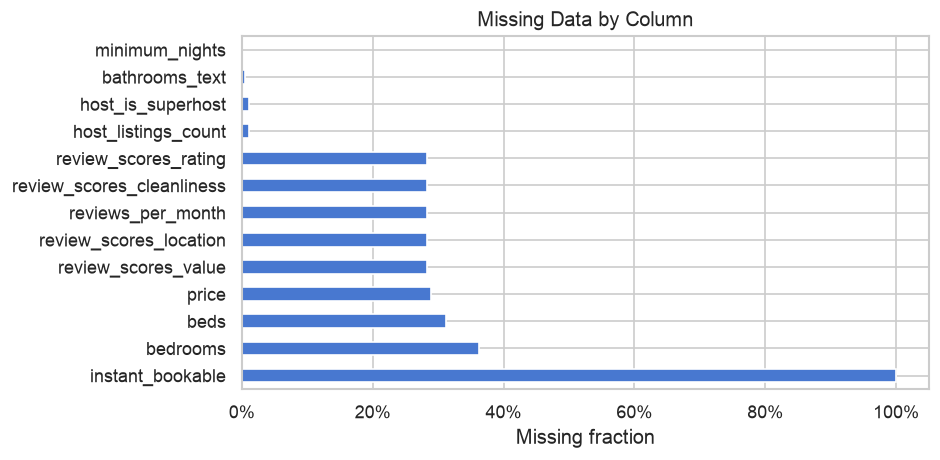

,missing_pct
instant_bookable,1.000000
bedrooms,0.362636
beds,0.311312
price,0.288972
review_scores_value,0.283155
review_scores_location,0.283155
reviews_per_month,0.282858
review_scores_cleanliness,0.282858
review_scores_rating,0.282858
host_listings_count,0.011534


In [17]:
miss = df.isnull().mean().sort_values(ascending=False)
miss = miss[miss > 0]

fig, ax = plt.subplots(figsize=(8, 4))
miss.plot(kind='barh', ax=ax)
ax.set_xlabel('Missing fraction')
ax.set_title('Missing Data by Column')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.savefig('../reports/figures/01_missingness.png', bbox_inches='tight')
plt.show()

miss.to_frame('missing_pct')

In [18]:
# Drop any columns that are entirely null — no signal possible
fully_null = miss[miss == 1.0].index.tolist()
if fully_null:
    print(f'Dropping 100% null columns: {fully_null}')
    df.drop(columns=fully_null, inplace=True)
else:
    print('No fully null columns found.')

print(f'Shape after drop: {df.shape}')

Dropping 100% null columns: ['instant_bookable']
Shape after drop: (30259, 25)


## 3. Price Cleaning

In [19]:
# Parse "$113.97" → 113.97
df['price'] = df['price'].str.replace(r'[\$,]', '', regex=True).astype(float)

# Drop rows with no price
before = len(df)
df = df.dropna(subset=['price'])
print(f'Dropped {before - len(df)} rows with null price')

# Remove extreme outliers: price > $2000 or price == 0
df = df[(df['price'] > 0) & (df['price'] <= 2000)]
print(f'After outlier removal: {len(df):,} rows')

df['price'].describe().round(2)

Dropped 8744 rows with null price
After outlier removal: 21,351 rows


count    21351.00
mean       246.31
std        240.00
min          4.58
25%         96.24
50%        173.12
75%        297.93
max       1999.25
Name: price, dtype: float64

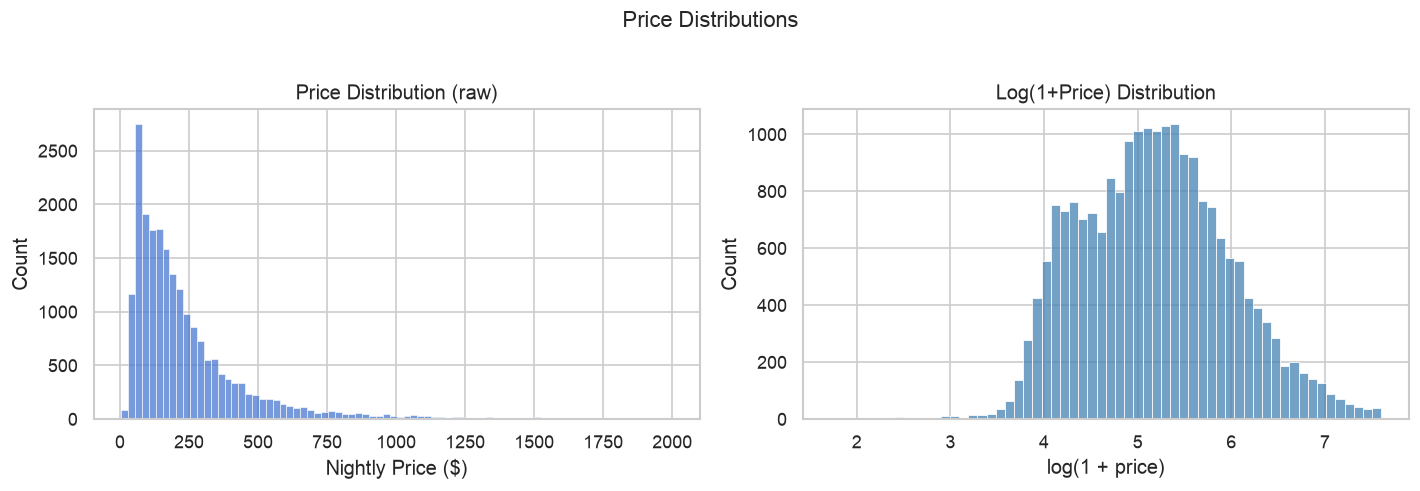

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['price'], bins=80, ax=axes[0])
axes[0].set_title('Price Distribution (raw)')
axes[0].set_xlabel('Nightly Price ($)')

sns.histplot(np.log1p(df['price']), bins=60, ax=axes[1], color='steelblue')
axes[1].set_title('Log(1+Price) Distribution')
axes[1].set_xlabel('log(1 + price)')

plt.suptitle('Price Distributions', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig('../reports/figures/01_price_distributions.png', bbox_inches='tight')
plt.show()

## 4. Price by Room Type

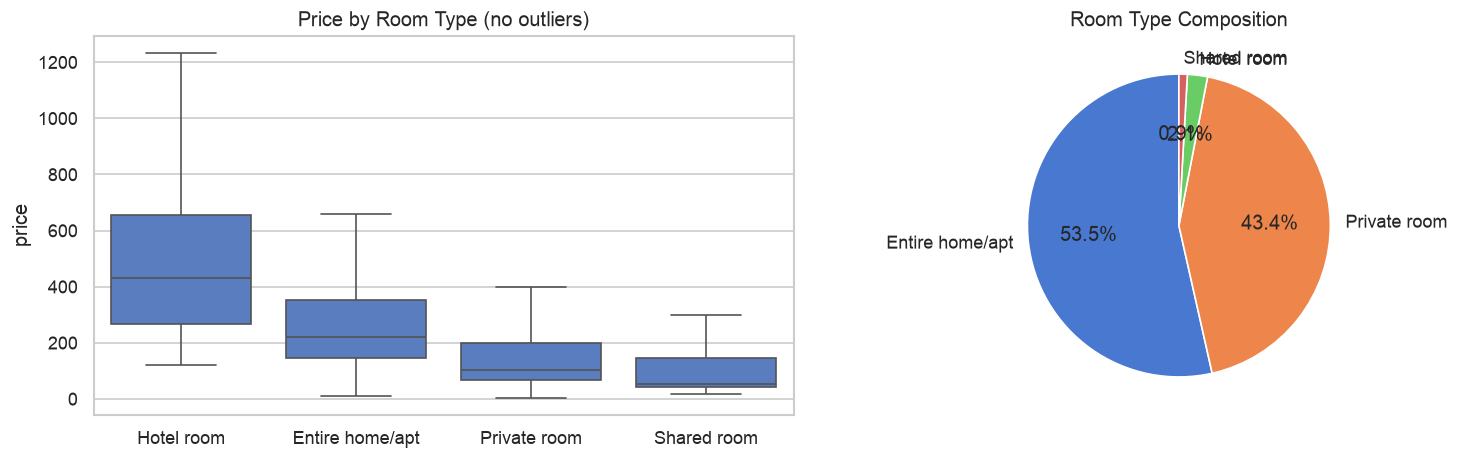

,count,median,mean
room_type,,,
Entire home/apt,11429,221.3,297.0
Hotel room,457,432.0,528.1
Private room,9274,102.5,171.9
Shared room,191,54.0,149.7


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

order = df.groupby('room_type')['price'].median().sort_values(ascending=False).index

sns.boxplot(data=df, x='room_type', y='price', order=order, ax=axes[0], showfliers=False)
axes[0].set_title('Price by Room Type (no outliers)')
axes[0].set_xlabel('')

room_counts = df['room_type'].value_counts()
axes[1].pie(room_counts, labels=room_counts.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Room Type Composition')

plt.tight_layout()
plt.savefig('../reports/figures/01_room_type.png', bbox_inches='tight')
plt.show()

df.groupby('room_type')['price'].agg(['count','median','mean']).round(1)

## 5. Price by Borough & Neighbourhood

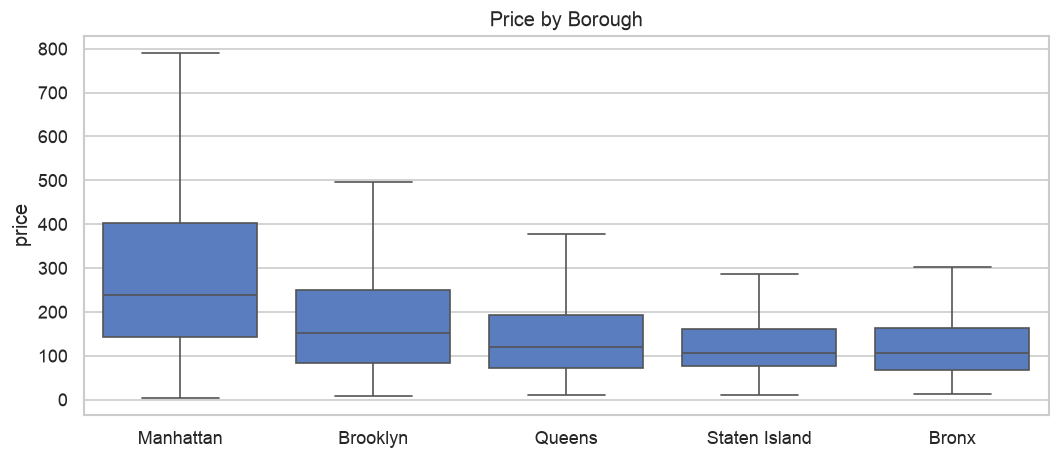

In [22]:
fig, ax = plt.subplots(figsize=(9, 4))
borough_order = df.groupby('neighbourhood_group_cleansed')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='neighbourhood_group_cleansed', y='price', order=borough_order, showfliers=False, ax=ax)
ax.set_title('Price by Borough')
ax.set_xlabel('')
plt.tight_layout()
plt.savefig('../reports/figures/01_borough_price.png', bbox_inches='tight')
plt.show()

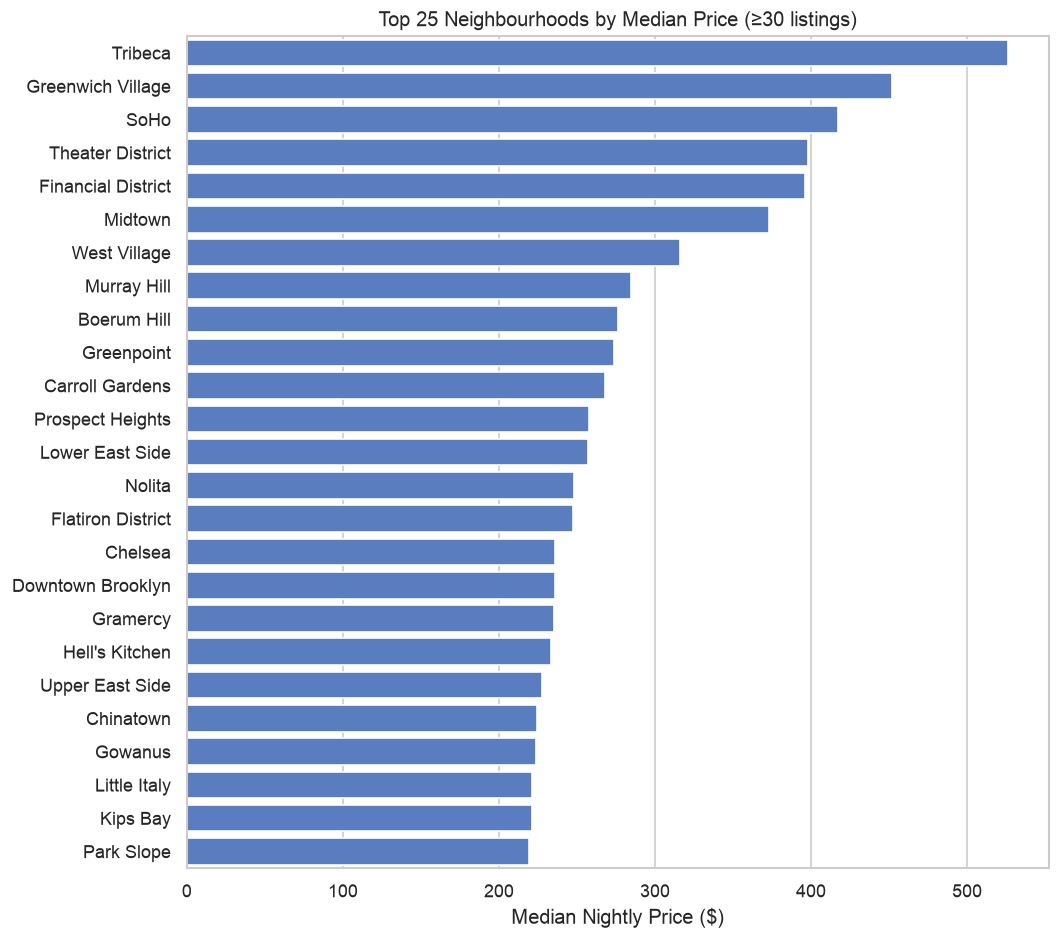

In [23]:
# Top 25 neighbourhoods by median price
top_neigh = (
    df.groupby('neighbourhood_cleansed')['price']
    .agg(median='median', count='count')
    .query('count >= 30')
    .sort_values('median', ascending=False)
    .head(25)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 8))
sns.barplot(data=top_neigh, x='median', y='neighbourhood_cleansed', ax=ax)
ax.set_title('Top 25 Neighbourhoods by Median Price (≥30 listings)')
ax.set_xlabel('Median Nightly Price ($)')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('../reports/figures/01_neighbourhood_price.png', bbox_inches='tight')
plt.show()

In [24]:
# Geographic price map
fig = px.scatter_mapbox(
    df.sample(5000, random_state=42),
    lat='latitude', lon='longitude', color='price',
    color_continuous_scale='Plasma',
    range_color=[df['price'].quantile(0.05), df['price'].quantile(0.95)],
    mapbox_style='carto-positron',
    zoom=10, opacity=0.5, height=500,
    title='NYC Airbnb Listing Prices (sample 5k)'
)
fig.write_html('../reports/figures/01_price_map.html')
print('Map saved → reports/figures/01_price_map.html')

Map saved → reports/figures/01_price_map.html


## 6. Property Size Features

In [25]:
# Parse bathrooms from text
def parse_bathrooms(txt):
    if pd.isna(txt):
        return np.nan
    import re
    m = re.search(r'[\d\.]+', str(txt))
    return float(m.group()) if m else np.nan

df['bathrooms'] = df['bathrooms_text'].apply(parse_bathrooms)
df['is_shared_bath'] = df['bathrooms_text'].str.lower().str.contains('shared', na=False).astype(int)

size_cols = ['accommodates', 'bedrooms', 'beds', 'bathrooms']
print(df[size_cols].describe().round(2))

       accommodates  bedrooms      beds  bathrooms
count      21351.00  13832.00  19628.00   21133.00
mean           2.92      1.59      1.72       1.19
std            2.07      0.90      1.19       0.50
min            1.00      0.00      1.00       0.00
25%            2.00      1.00      1.00       1.00
50%            2.00      1.00      1.00       1.00
75%            4.00      2.00      2.00       1.00
max           16.00     12.00     18.00      10.50


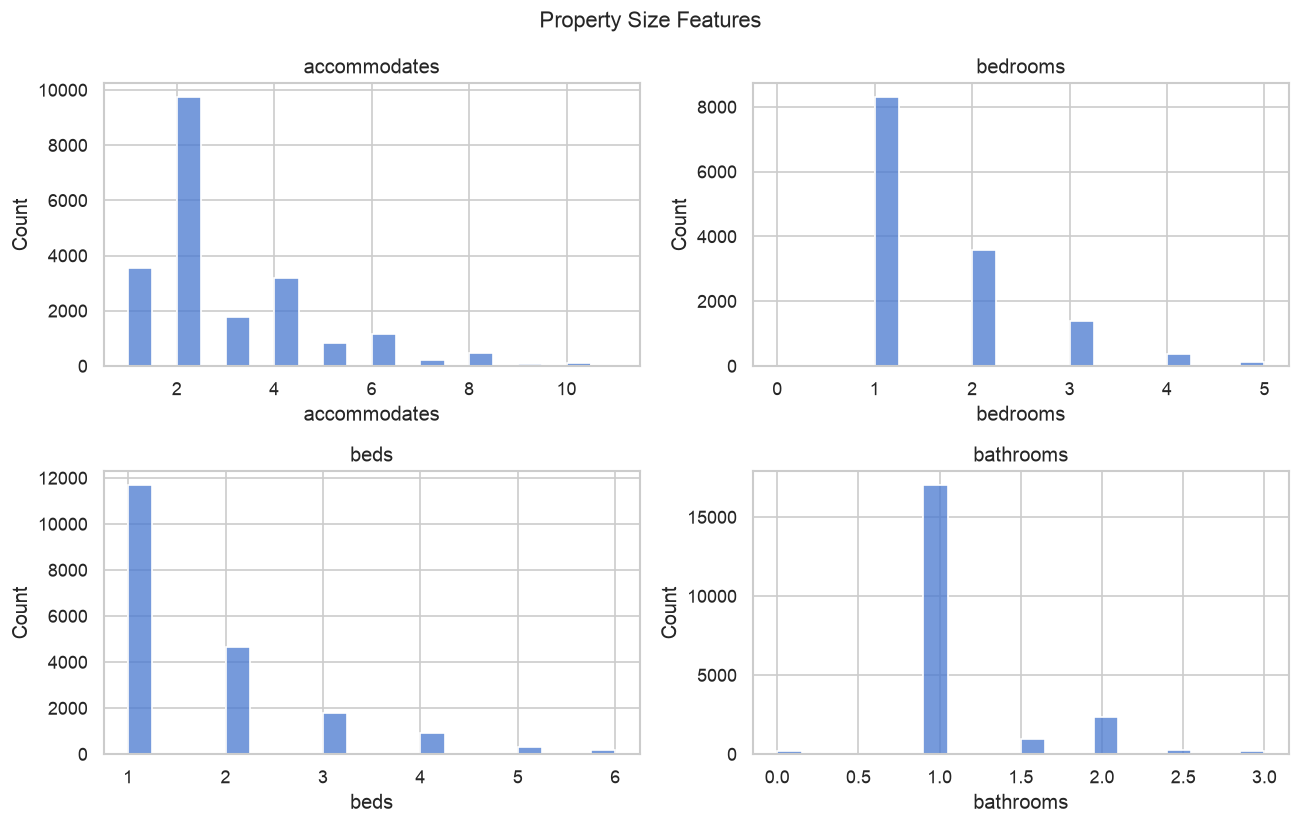

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, col in zip(axes.flat, size_cols):
    data = df[col].dropna()
    data = data[data <= data.quantile(0.99)]
    sns.histplot(data, bins=20, ax=ax)
    ax.set_title(col)
plt.suptitle('Property Size Features', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/figures/01_size_features.png', bbox_inches='tight')
plt.show()

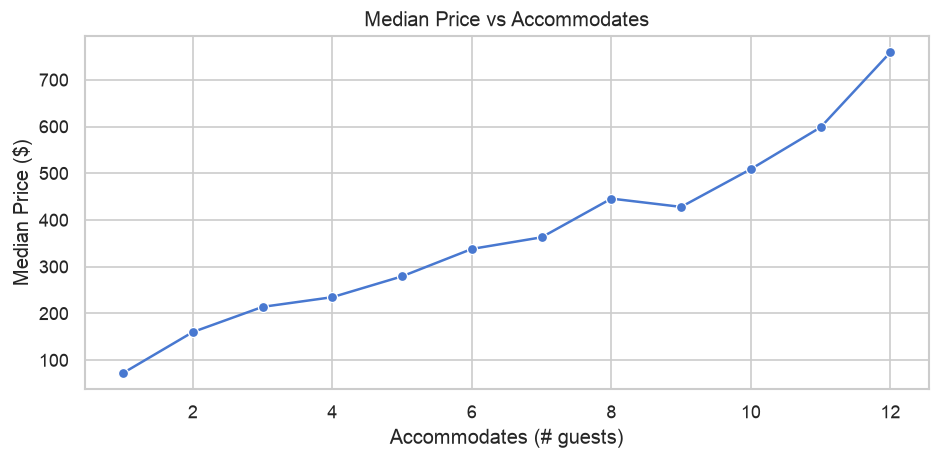

In [27]:
# Price vs accommodates
acc_price = df.groupby('accommodates')['price'].median().reset_index()
acc_price = acc_price[acc_price['accommodates'] <= 12]

fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(data=acc_price, x='accommodates', y='price', marker='o', ax=ax)
ax.set_title('Median Price vs Accommodates')
ax.set_xlabel('Accommodates (# guests)')
ax.set_ylabel('Median Price ($)')
plt.tight_layout()
plt.savefig('../reports/figures/01_price_vs_accommodates.png', bbox_inches='tight')
plt.show()

## 7. Review Scores & Host Features

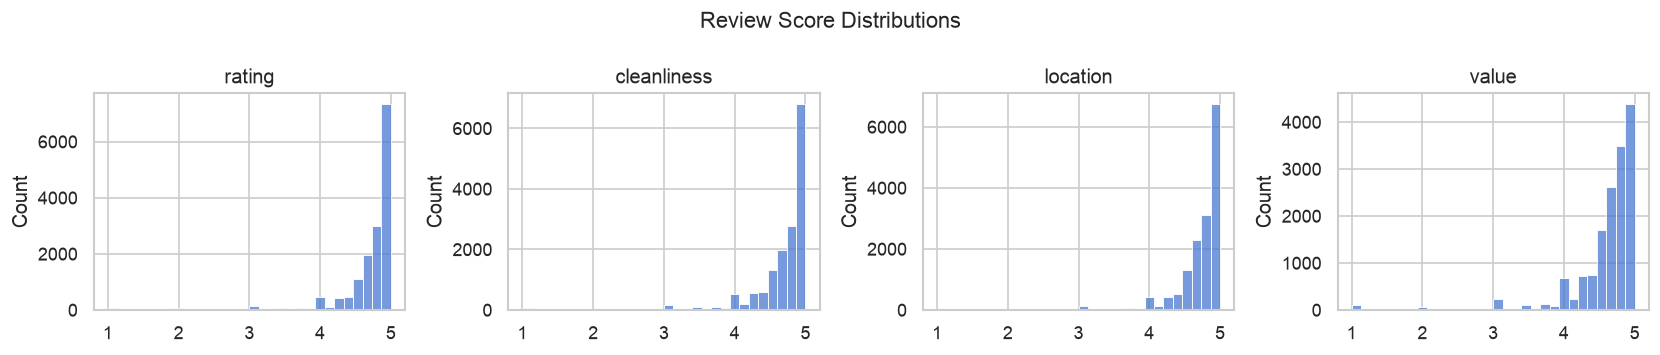

In [28]:
review_cols = ['review_scores_rating', 'review_scores_cleanliness',
               'review_scores_location', 'review_scores_value']

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for ax, col in zip(axes, review_cols):
    sns.histplot(df[col].dropna(), bins=30, ax=ax)
    ax.set_title(col.replace('review_scores_', ''))
    ax.set_xlabel('')
plt.suptitle('Review Score Distributions', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/figures/01_review_scores.png', bbox_inches='tight')
plt.show()

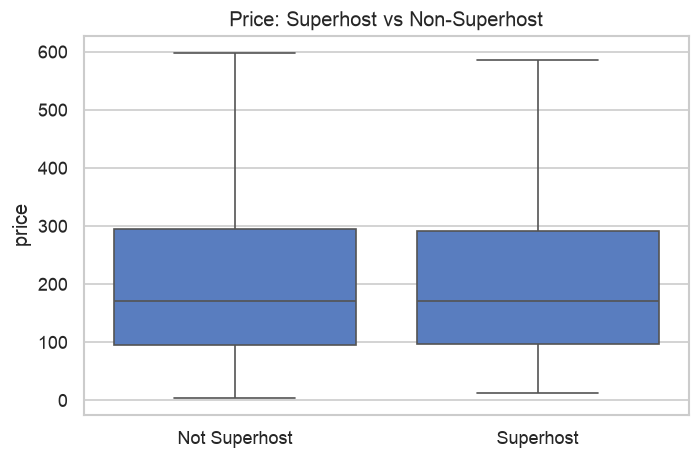

host_is_superhost
0.0    171.375
1.0    171.400
Name: price, dtype: float64

In [29]:
# Superhost price premium
df['host_is_superhost'] = df['host_is_superhost'].map({'t': 1, 'f': 0, True: 1, False: 0})

fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=df.dropna(subset=['host_is_superhost']),
            x='host_is_superhost', y='price', showfliers=False, ax=ax)
ax.set_xticklabels(['Not Superhost', 'Superhost'])
ax.set_title('Price: Superhost vs Non-Superhost')
ax.set_xlabel('')
plt.tight_layout()
plt.savefig('../reports/figures/01_superhost_price.png', bbox_inches='tight')
plt.show()

df.groupby('host_is_superhost')['price'].median()

## 8. Correlation Heatmap

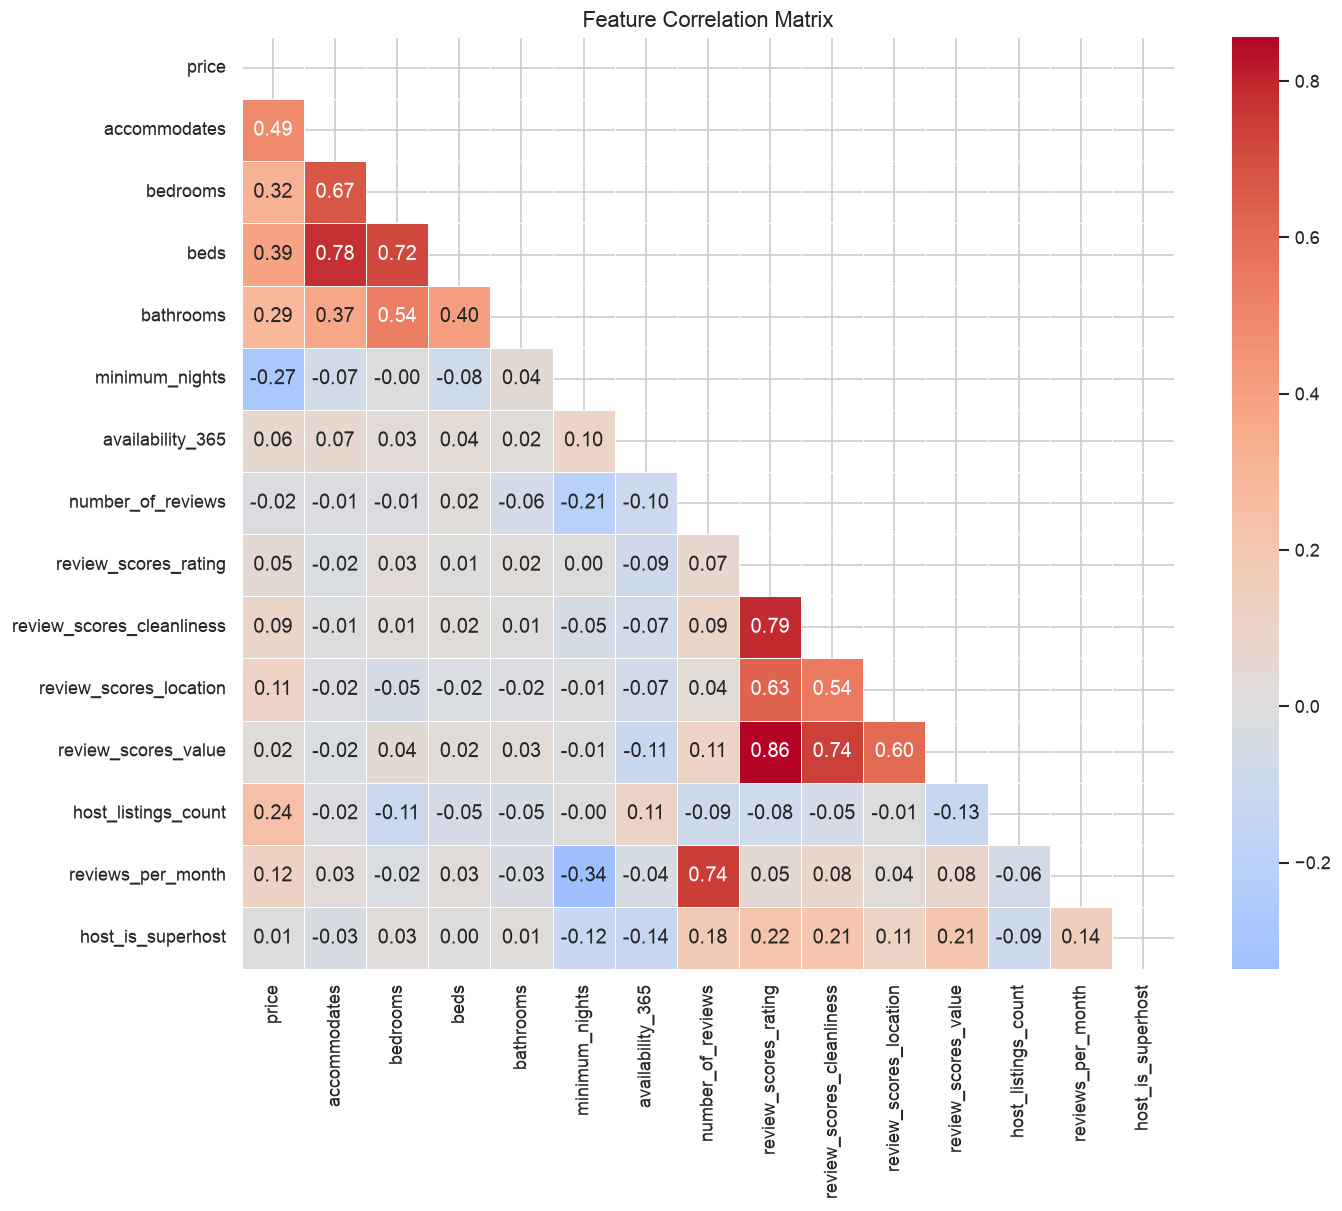

In [30]:
num_cols = [
    'price', 'accommodates', 'bedrooms', 'beds', 'bathrooms',
    'minimum_nights', 'availability_365', 'number_of_reviews',
    'review_scores_rating', 'review_scores_cleanliness',
    'review_scores_location', 'review_scores_value',
    'host_listings_count', 'reviews_per_month', 'host_is_superhost'
]

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/figures/01_correlation_heatmap.png', bbox_inches='tight')
plt.show()

In [31]:
# Correlations with price, sorted
corr['price'].drop('price').sort_values(key=abs, ascending=False).to_frame('corr_with_price')

,corr_with_price
accommodates,0.491498
beds,0.390960
bedrooms,0.320183
bathrooms,0.287295
minimum_nights,-0.274482
host_listings_count,0.236516
reviews_per_month,0.117449
review_scores_location,0.112048
review_scores_cleanliness,0.087876
availability_365,0.063287


## 9. Availability & Minimum Nights

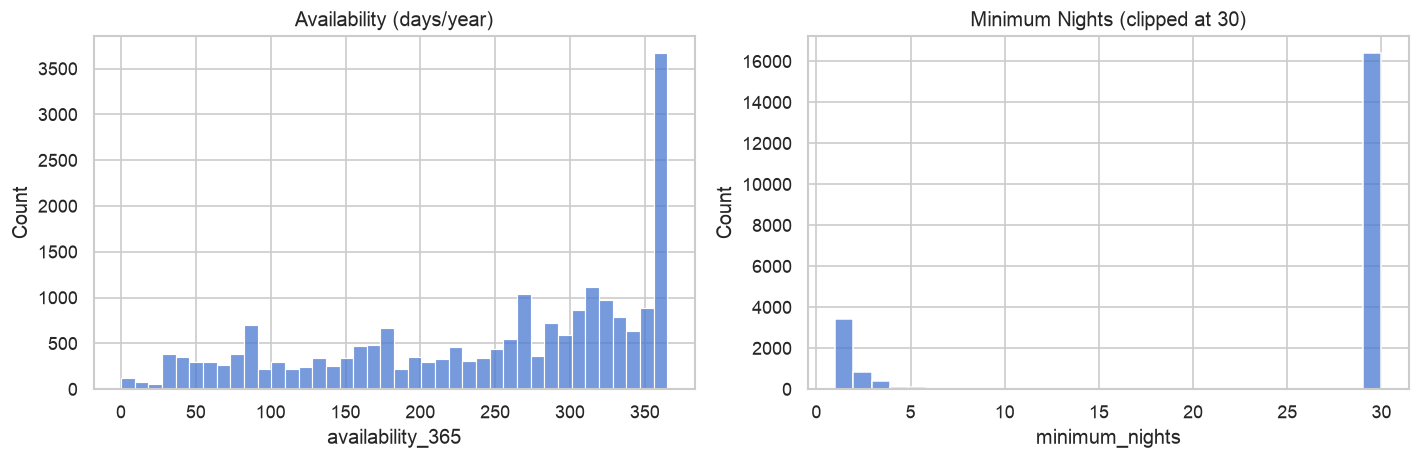

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['availability_365'], bins=40, ax=axes[0])
axes[0].set_title('Availability (days/year)')

mn = df['minimum_nights'].clip(upper=30)
sns.histplot(mn, bins=30, ax=axes[1])
axes[1].set_title('Minimum Nights (clipped at 30)')

plt.tight_layout()
plt.savefig('../reports/figures/01_availability.png', bbox_inches='tight')
plt.show()

## 10. Save Cleaned Dataset

In [33]:
# Fill simple missingness before saving
df['bedrooms'] = df['bedrooms'].fillna(df['bedrooms'].median())
df['beds'] = df['beds'].fillna(df['beds'].median())
df['bathrooms'] = df['bathrooms'].fillna(df['bathrooms'].median())
df['review_scores_rating'] = df['review_scores_rating'].fillna(df['review_scores_rating'].median())
df['review_scores_cleanliness'] = df['review_scores_cleanliness'].fillna(df['review_scores_cleanliness'].median())
df['review_scores_location'] = df['review_scores_location'].fillna(df['review_scores_location'].median())
df['review_scores_value'] = df['review_scores_value'].fillna(df['review_scores_value'].median())
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)
df['host_listings_count'] = df['host_listings_count'].fillna(1)
df['host_is_superhost'] = df['host_is_superhost'].fillna(0)

df.to_csv(PROCESSED, index=False)
print(f'Saved {len(df):,} rows → {PROCESSED}')
df.shape

Saved 21,351 rows → ../data/processed/listings_clean.csv


(21351, 27)

## EDA Summary

| Finding | Detail |
|---|---|
| Dataset size | ~21k usable rows after price filtering |
| Price range | $5–$2,000/night; median ~$175 |
| Target transform | log(1+price) normalizes the right skew well |
| Strongest predictor | `room_type` and `accommodates` |
| Geographic signal | Manhattan commands clear premium; neighbourhood is informative |
| Superhost premium | Small but consistent (~$10–15 median lift) |
| Key missingness | `bedrooms`, `beds`, `bathrooms` (~30–35%) — imputed with median |
| Outliers removed | Price > $2,000 (~164 rows, <1%) |